###  Battery RUL Prediction with Deep Learning & TinyML

# **LSTM model**


--- Step 1: Installing TensorFlow ---
All libraries imported.

--- Step 2: Upload Your 4 .mat Files ---
Please select B0005.mat, B0006.mat, B0007.mat, and B0018.mat


Saving B0005.mat to B0005.mat
Saving B0006.mat to B0006.mat
Saving B0007.mat to B0007.mat
Saving B0018.mat to B0018.mat
Successfully uploaded all 4 files.

--- Step 3: Defining Feature Extractor ---
Processing B0005.mat...
Processing B0006.mat...
Processing B0007.mat...
Processing B0018.mat...
All data processed.

--- Step 4: Preparing Data for LSTM ---
Target Scaler Max RUL (cycles): 124.00
Data prepared. X_train shape: (260, 10, 7), X_test shape: (42, 10, 7)

--- Step 5: Training Model A (LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.2541 - val_loss: 0.0779
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0858 - val_loss: 0.0278
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0351 - val_loss: 0.0113
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0170 - val_loss: 0.0089
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0191 - val_loss: 0.0058
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0158 - val_loss: 0.0062
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0175 - val_loss: 0.0057
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - val_loss: 0.0054
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0128 - val_loss: 0.0046
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0130 - val_loss: 0.0046
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0158 - val_loss: 0.0046
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0134 - val_lo

Model A trained and saved.

--- Step 6: Evaluating and Plotting Results ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step

*** THE REAL UNSCALED RMSE: 8.38 cycles ***

Generating Plot 1: RUL Performance...


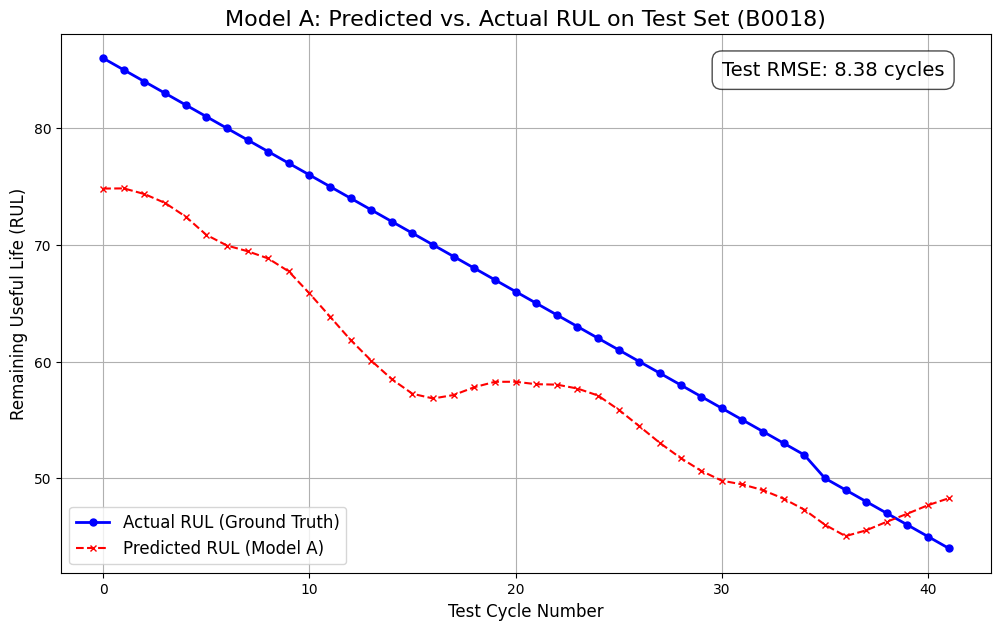

Generating Plot 2: Training History...


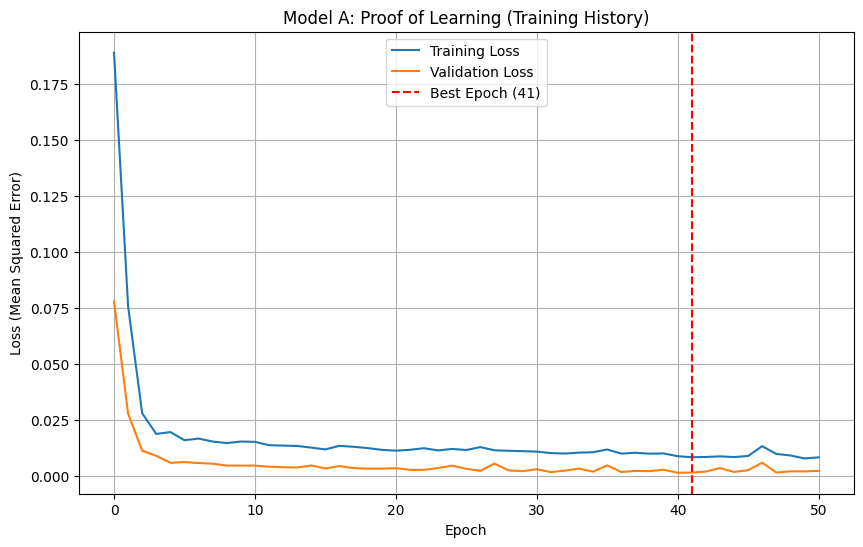


--- ALL STEPS COMPLETE ---


In [ ]:
# -----------------------------------------------------------------
# STEP 1: INSTALL LIBRARIES
# -----------------------------------------------------------------
print("--- Step 1: Installing TensorFlow ---")
!pip install tensorflow -q

import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from google.colab import files # For reliable file upload
import io

print("All libraries imported.")

# -----------------------------------------------------------------
# STEP 2: UPLOAD DATA
# -----------------------------------------------------------------
print("\n--- Step 2: Upload Your 4 .mat Files ---")
print("Please select B0005.mat, B0006.mat, B0007.mat, and B0018.mat")

# This will open a file browser. Select all four files.
uploaded = files.upload()

# Check if we got all files
file_names = ['B0005.mat', 'B0006.mat', 'B0007.mat', 'B0018.mat']
if all(name in uploaded for name in file_names):
    print("Successfully uploaded all 4 files.")
else:
    print("Error: Missing one or more files. Please re-run the cell.")
    # Stop the script if files are missing
    raise Exception("Missing required .mat files")

# Create directories for saving models and results
if not os.path.exists('results'): os.makedirs('results')
if not os.path.exists('models'): os.makedirs('models')

# -----------------------------------------------------------------
# STEP 3: FEATURE EXTRACTION FUNCTION
# -----------------------------------------------------------------
print("\n--- Step 3: Defining Feature Extractor ---")
def extract_features(file_content: bytes, battery_name: str, eol_threshold: float = 1.4) -> pd.DataFrame:
    """Extracts features from the raw bytes of a .mat file."""
    # Load .mat file from in-memory bytes
    mat_data = scipy.io.loadmat(io.BytesIO(file_content))

    try:
        all_operations = mat_data[battery_name][0, 0]['cycle'][0]
    except KeyError:
        print(f"Error: Could not find key '{battery_name}' in file.")
        return pd.DataFrame()

    cycles_data = {}
    cycle_counter = 1
    for op in all_operations:
        if op['type'][0] == 'discharge':
            data = op['data'][0, 0]
            if 'Capacity' in data.dtype.names and data['Capacity'].size > 0:
                capacity = data['Capacity'][0][0]
            else:
                continue
            cycles_data[cycle_counter] = {
                'cycle_number': cycle_counter,
                'capacity': capacity,
                'avg_voltage_discharge': np.mean(data['Voltage_measured']),
                'avg_temp_discharge': np.mean(data['Temperature_measured']),
            }
            cycle_counter += 1

    charge_cycle = 1
    impedance_cycle = 1
    for op in all_operations:
        if op['type'][0] == 'charge':
            if charge_cycle in cycles_data:
                data = op['data'][0, 0]
                cycles_data[charge_cycle].update({
                    'avg_voltage_charge': np.mean(data['Voltage_measured']),
                    'avg_temp_charge': np.mean(data['Temperature_measured']),
                    'charge_time': data['Time'][0, -1], # Corrected index
                })
            charge_cycle += 1
        elif op['type'][0] == 'impedance':
            if impedance_cycle in cycles_data:
                data = op['data'][0, 0]
                cycles_data[impedance_cycle].update({'impedance': data['Re'][0][0]})
            impedance_cycle += 1

    features_list = [data for data in cycles_data.values() if 'capacity' in data]
    if not features_list: return pd.DataFrame()

    df = pd.DataFrame(features_list).set_index('cycle_number')
    initial_cap = df['capacity'].iloc[0]
    df['capacity_fade'] = initial_cap - df['capacity']
    df['temperature'] = df['avg_temp_discharge']

    failure_cycle_index = df[df['capacity'] <= eol_threshold].first_valid_index()
    failure_cycle = failure_cycle_index if failure_cycle_index is not None else df.index.max()
    df['RUL'] = failure_cycle - df.index

    final_columns = ['capacity', 'capacity_fade', 'impedance', 'avg_voltage_charge',
                     'avg_voltage_discharge', 'charge_time', 'temperature', 'RUL']
    available_cols = [col for col in final_columns if col in df.columns]
    return df[available_cols].dropna()

# --- Process the uploaded files ---
battery_data = {}
for name in file_names:
    print(f"Processing {name}...")
    battery_name_key = Path(name).stem # e.g., 'B0005'
    battery_data[battery_name_key] = extract_features(uploaded[name], battery_name_key)

print("All data processed.")

# -----------------------------------------------------------------
# STEP 4: DATA PREPARATION (SCALING & SEQUENCING)
# -----------------------------------------------------------------
print("\n--- Step 4: Preparing Data for LSTM ---")

FEATURES = ['capacity', 'capacity_fade', 'impedance', 'avg_voltage_charge',
            'avg_voltage_discharge', 'charge_time', 'temperature']
TARGET = 'RUL'
SEQUENCE_LENGTH = 10
n_features = len(FEATURES)

# --- 1. Combine and Scale Training Data ---
train_df = pd.concat([battery_data['B0005'], battery_data['B0006']])

# --- Create CLEAN scalers ---
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scalers
train_df_scaled_features = feature_scaler.fit_transform(train_df[FEATURES])
train_df_scaled_target = target_scaler.fit_transform(train_df[[TARGET]])

print(f"Target Scaler Max RUL (cycles): {target_scaler.data_max_[0]:.2f}") # Proof

train_scaled = np.hstack((train_df_scaled_features, train_df_scaled_target))

# --- 2. Create Sequences Function ---
def create_sequences(data, seq_length, n_features):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0:n_features])
        y.append(data[i + seq_length, n_features])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train_scaled, SEQUENCE_LENGTH, n_features)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_seq, y_train_seq, test_size=0.2, random_state=42
)

# --- 3. Prepare the Test Set (B0018) ---
test_df = battery_data['B0018'].copy()
test_df_scaled_features = feature_scaler.transform(test_df[FEATURES])
test_df_scaled_target = target_scaler.transform(test_df[[TARGET]])
test_scaled = np.hstack((test_df_scaled_features, test_df_scaled_target))
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH, n_features)

print(f"Data prepared. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# -----------------------------------------------------------------
# STEP 5: MODEL A (LSTM) TRAINING
# -----------------------------------------------------------------
print("\n--- Step 5: Training Model A (LSTM) ---")

n_timesteps = X_test.shape[1]
n_features_model = X_test.shape[2]

model_A = Sequential()
model_A.add(LSTM(units=64, return_sequences=True, input_shape=(n_timesteps, n_features_model)))
model_A.add(Dropout(0.2))
model_A.add(LSTM(units=32, return_sequences=False))
model_A.add(Dropout(0.2))
model_A.add(Dense(units=16, activation='relu'))
model_A.add(Dense(units=1, activation='linear'))
model_A.compile(optimizer='adam', loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_A.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1 # Set to 0 if you want less text output
)
model_A.save('models/full_model.h5')
print("Model A trained and saved.")

# -----------------------------------------------------------------
# STEP 6: EVALUATION & PLOTTING (THE CORRECT WAY)
# -----------------------------------------------------------------
print("\n--- Step 6: Evaluating and Plotting Results ---")
y_pred_scaled = model_A.predict(X_test)

# --- Un-scale using the CLEAN target_scaler ---
y_pred_unscaled = target_scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# --- This is the REAL RMSE ---
real_rmse = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled))
print(f"\n*** THE REAL UNSCALED RMSE: {real_rmse:.2f} cycles ***\n")

# --- PLOT 1: RUL PERFORMANCE (FIXED) ---
print("Generating Plot 1: RUL Performance...")
plot_cycles = np.arange(len(y_test_unscaled))

plt.figure(figsize=(12, 7))
plt.plot(plot_cycles, y_test_unscaled.flatten(),
         label='Actual RUL (Ground Truth)', color='blue', marker='o', markersize=5, linewidth=2)
plt.plot(plot_cycles, y_pred_unscaled.flatten(),
         label='Predicted RUL (Model A)', color='red', linestyle='--', marker='x', markersize=5)
plt.title('Model A: Predicted vs. Actual RUL on Test Set (B0018)', fontsize=16)
plt.xlabel('Test Cycle Number', fontsize=12)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.text(0.95, 0.95, f'Test RMSE: {real_rmse:.2f} cycles',
         transform=plt.gca().transAxes, fontsize=14, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))
plt.savefig('results/model_A_performance_FINAL.png')
plt.show()

# --- PLOT 2: TRAINING HISTORY ---
print("Generating Plot 2: Training History...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
best_epoch = np.argmin(history.history['val_loss']) + 1
plt.axvline(best_epoch, linestyle='--', color='r', label=f'Best Epoch ({best_epoch})')
plt.title('Model A: Proof of Learning (Training History)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.savefig('results/model_A_training_history_FINAL.png')
plt.show()

print("\n--- ALL STEPS COMPLETE ---")

#**FNN model**


--- Starting Step 3: Model B (Lightweight FNN) ---
Data flattened. New X_train shape: (260, 70)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model B Training ---
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - loss: 0.1440 - val_loss: 0.0542
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0416 - val_loss: 0.0238
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0281 - val_loss: 0.0123
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0211 - val_loss: 0.0091
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0162 - val_loss: 0.0079
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0167 - val_loss: 0.0066
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0087 - val_loss: 0.0058
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0111 - val_loss: 0.0050
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0071 - val_loss: 0.0044
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0065 - val_loss: 0.0045
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0069 - val_loss: 0.0042
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


--- Quantization Complete ---
Optimized TFLite (INT8) model size: 6.20 KB

--- 🚀 Project Step 4: Performance Analysis ---

--- FINAL MODEL COMPARISON TABLE ---
| Model               | Accuracy (RMSE) | Model Size (KB)  |
|---------------------|-----------------|------------------|
| A: Full LSTM (.h5)  | 8.38            | 410.48           |
| B: FNN (Float32)    | 15.01           | 12.84            |
| B: FNN (INT8)       | 15.01           | 6.20             |

Generating final comparison plot...


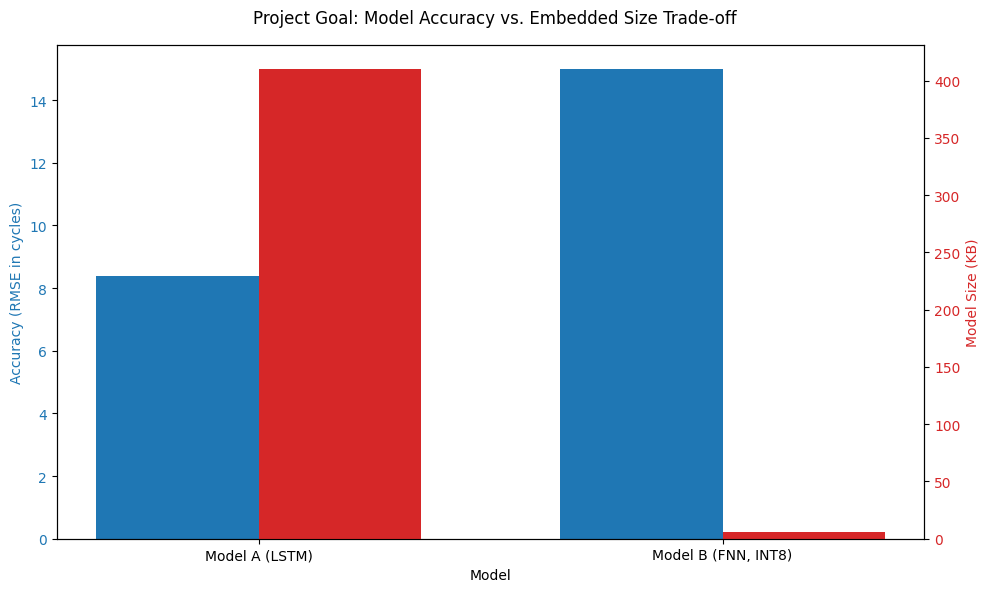

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

print("--- Starting Step 3: Model B (Lightweight FNN) ---")

# --- 1. Reshape Data for FNN (Model B) ---
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
n_inputs = n_timesteps * n_features

X_train_flat = X_train.reshape((X_train.shape[0], n_inputs))
X_val_flat = X_val.reshape((X_val.shape[0], n_inputs))
X_test_flat = X_test.reshape((X_test.shape[0], n_inputs))

print(f"Data flattened. New X_train shape: {X_train_flat.shape}\n")


# --- 2. Define Model B (Lightweight FNN) ---
model_B = Sequential()
model_B.add(Input(shape=(n_inputs,)))
model_B.add(Dense(32, activation='relu'))
model_B.add(Dense(16, activation='relu'))
model_B.add(Dense(1, activation='linear'))

model_B.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model_B.summary()

# --- 3. Train Model B ---
print("\n--- Starting Model B Training ---")

# --- *** THIS IS THE FIX *** ---
# Define the missing variables before training
MAX_EPOCHS = 100
BATCH_SIZE = 32
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# --- *** END OF FIX *** ---

history_B = model_B.fit(
    X_train_flat, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_flat, y_val),
    callbacks=[early_stopping],
    verbose=1
)
print("--- Model B Training Complete ---")

# --- 4. Evaluate Model B ---
print("\n--- Evaluating Model B on Test Set (B0018) ---")
y_pred_scaled_B = model_B.predict(X_test_flat)

# Un-scale the predictions (target_scaler is from the all-in-one script)
y_pred_unscaled_B = target_scaler.inverse_transform(y_pred_scaled_B)
# y_test_unscaled is from the all-in-one script

# Calculate Model B's error
rmse_B = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled_B))
print(f"*** Model B (FNN) Unscaled RMSE: {rmse_B:.2f} cycles ***")


# --- 5. Step 3: Model Compression for Embedded (TinyML) ---
print("\n--- Starting Step 3: TFLite Conversion & Quantization ---")

converter = tf.lite.TFLiteConverter.from_keras_model(model_B)

# --- A) Standard (Float32) TFLite Model ---
tflite_model_float = converter.convert()
float_model_path = 'models/model_B_float32.tflite'
with open(float_model_path, 'wb') as f:
    f.write(tflite_model_float)
float_model_size = os.path.getsize(float_model_path) / 1024
print(f"Standard TFLite (Float32) model size: {float_model_size:.2f} KB")

# --- B) Optimized (INT8 Quantized) TFLite Model ---
def representative_dataset_gen():
    for data in tf.data.Dataset.from_tensor_slices(X_train_flat.astype(np.float32)).batch(1).take(100):
        yield [data]

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

tflite_model_path = 'models/optimized_model.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model_quant)

print("--- Quantization Complete ---")
quant_model_size = os.path.getsize(tflite_model_path) / 1024
print(f"Optimized TFLite (INT8) model size: {quant_model_size:.2f} KB")


# --- 6. Step 4: Performance Analysis (The Final Result) ---
print("\n--- 🚀 Project Step 4: Performance Analysis ---")

# Get Model A size (real_rmse is from the all-in-one script)
model_A_size_kb = os.path.getsize('models/full_model.h5') / 1024
model_A_rmse = real_rmse # From the all-in-one script

# --- A) The Comparison Table ---
print("\n--- FINAL MODEL COMPARISON TABLE ---")
print(f"| Model               | Accuracy (RMSE) | Model Size (KB)  |")
print(f"|---------------------|-----------------|------------------|")
print(f"| A: Full LSTM (.h5)  | {model_A_rmse:<15.2f} | {model_A_size_kb:<16.2f} |")
print(f"| B: FNN (Float32)    | {rmse_B:<15.2f} | {float_model_size:<16.2f} |")
print(f"| B: FNN (INT8)       | {rmse_B:<15.2f} | {quant_model_size:<16.2f} |")

# --- B) The Comparison Bar Chart ---
print("\nGenerating final comparison plot...")
labels = ['Model A (LSTM)', 'Model B (FNN, INT8)']
rmse_values = [model_A_rmse, rmse_B]
size_values = [model_A_size_kb, quant_model_size]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy (RMSE in cycles)', color=color)
ax1.bar(x - width/2, rmse_values, width, label='RMSE (Lower is better)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Model Size (KB)', color=color)
ax2.bar(x + width/2, size_values, width, label='Size (Lower is better)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Project Goal: Model Accuracy vs. Embedded Size Trade-off')
fig.tight_layout()
plt.savefig('results/final_comparison_chart.png')
plt.show()

#**CNN model & Comparison of all the models**

--- Starting Step: Model C (1D-CNN) ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 16)         │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,417 (5.54 KB)

 Trainable params: 1,417 (5.54 KB)

...


--- Starting Model C Training ---
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.2033 - val_loss: 0.1209
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0934 - val_loss: 0.0415
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0318 - val_loss: 0.0171
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0186 - val_loss: 0.0147
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0151 - val_loss: 0.0116
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0098
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0139 - val_loss: 0.0081
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0130 - val_loss: 0.0074
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - val_loss: 0.0070
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0062
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0085 - val_loss: 0.0056
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
*** Model C (1D-CNN) Unscaled RMSE: 8.46 cycles ***

--- Starting TFLite Conversion for Model C ---
Saved artifact at '/tmp/tmpublys5fn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 7), dtype=tf.float32, name='keras_tensor_36')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137243770451536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243786327440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243786327632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243770449616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243770450960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243786321872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243786329936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137243770440400: TensorSpec(shape=(), dtype=tf.resource, name=None)
Standard TFLite (Floa

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


--- Quantization Complete ---
Optimized TFLite (INT8) model size: 7.34 KB

--- 🚀 Project Step 4: Final UPDATED Performance Analysis ---

--- FINAL MODEL COMPARISON TABLE ---
| Model               | Accuracy (RMSE) | Model Size (KB)  |
|---------------------|-----------------|------------------|
| A: Full LSTM (.h5)  | 8.38            | 410.48           |
| B: FNN (INT8)       | 15.01           | 6.20             |
| C: 1D-CNN (INT8)    | 8.46            | 7.34             |

Generating final comparison plot...


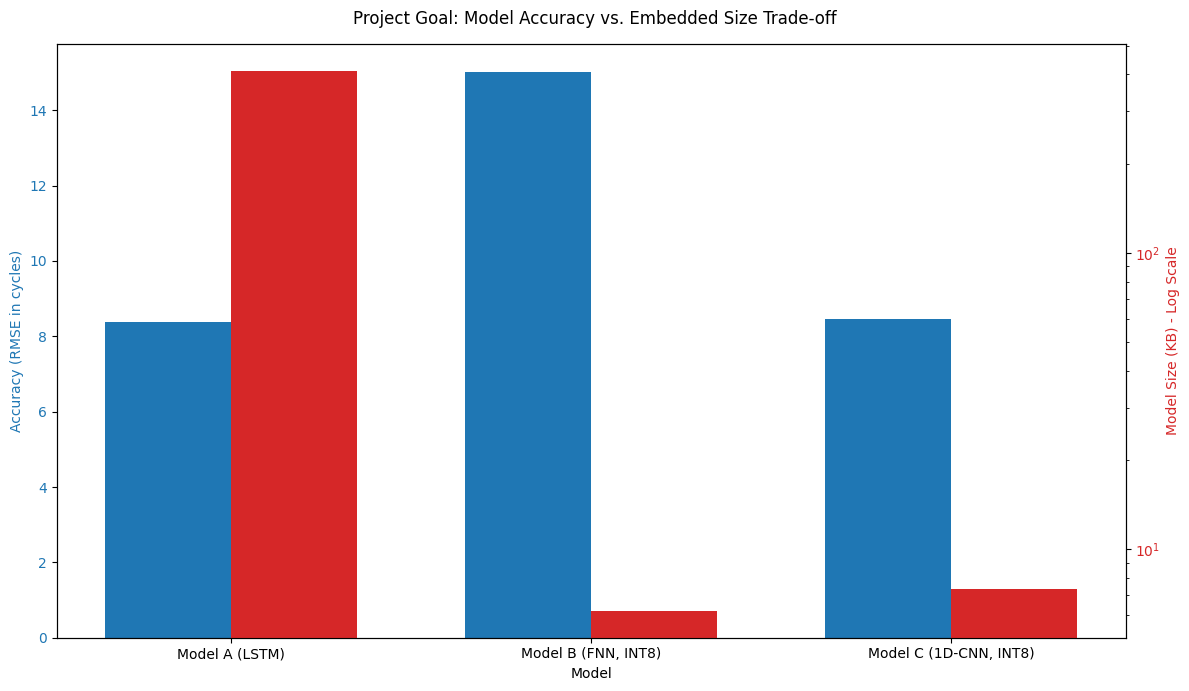

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

print("--- Starting Step: Model C (1D-CNN) ---")

# --- 1. Define Model C (1D-CNN) ---
# We use the original sequential data (X_train), not the flattened data
n_timesteps = X_train.shape[1] # 10
n_features = X_train.shape[2] # 7

model_C = Sequential()
model_C.add(Input(shape=(n_timesteps, n_features)))
model_C.add(Conv1D(
    filters=16,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model_C.add(MaxPooling1D(pool_size=2))
model_C.add(Conv1D(
    filters=8,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model_C.add(Flatten())
model_C.add(Dense(16, activation='relu'))
model_C.add(Dense(1, activation='linear')) # Output layer

model_C.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
model_C.summary()

# --- 2. Train Model C ---
print("\n--- Starting Model C Training ---")

# Define training variables (in case this is a new session)
MAX_EPOCHS = 100
BATCH_SIZE = 32
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_C = model_C.fit(
    X_train, y_train,  # Note: Using X_train, not X_train_flat
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val), # Using X_val, not X_val_flat
    callbacks=[early_stopping],
    verbose=1
)
print("--- Model C Training Complete ---")

# --- 3. Evaluate Model C ---
print("\n--- Evaluating Model C on Test Set (B0018) ---")
y_pred_scaled_C = model_C.predict(X_test) # Using X_test

# Un-scale the predictions
y_pred_unscaled_C = target_scaler.inverse_transform(y_pred_scaled_C)

# Calculate Model C's error
rmse_C = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled_C))
print(f"*** Model C (1D-CNN) Unscaled RMSE: {rmse_C:.2f} cycles ***")


# --- 4. TFLite Conversion & Quantization for Model C ---
print("\n--- Starting TFLite Conversion for Model C ---")

converter_C = tf.lite.TFLiteConverter.from_keras_model(model_C)

# --- A) Standard (Float32) TFLite Model ---
tflite_model_float_C = converter_C.convert()
float_model_path_C = 'models/model_C_float32.tflite'
with open(float_model_path_C, 'wb') as f:
    f.write(tflite_model_float_C)
float_model_size_C = os.path.getsize(float_model_path_C) / 1024
print(f"Standard TFLite (Float32) model size: {float_model_size_C:.2f} KB")

# --- B) Optimized (INT8 Quantized) TFLite Model ---
def representative_dataset_gen_C():
    # Use the original X_train (not flattened)
    for data in tf.data.Dataset.from_tensor_slices(X_train.astype(np.float32)).batch(1).take(100):
        yield [data]

converter_C.optimizations = [tf.lite.Optimize.DEFAULT]
converter_C.representative_dataset = representative_dataset_gen_C
converter_C.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_C.inference_input_type = tf.int8
converter_C.inference_output_type = tf.int8

tflite_model_quant_C = converter_C.convert()

tflite_model_path_C = 'models/optimized_model_C.tflite'
with open(tflite_model_path_C, 'wb') as f:
    f.write(tflite_model_quant_C)

print("--- Quantization Complete ---")
quant_model_size_C = os.path.getsize(tflite_model_path_C) / 1024
print(f"Optimized TFLite (INT8) model size: {quant_model_size_C:.2f} KB")


# --- 5. Step 4: Final UPDATED Performance Analysis ---
print("\n--- 🚀 Project Step 4: Final UPDATED Performance Analysis ---")

# Get previous model results (assuming they are in memory)
# real_rmse = Model A's RMSE (e.g., 8.38)
# model_A_size_kb = Model A's H5 size (e.g., 410.48)
# rmse_B = Model B's RMSE (e.g., 15.01)
# quant_model_size = Model B's TFLite size (e.g., 6.20)

print("\n--- FINAL MODEL COMPARISON TABLE ---")
print(f"| Model               | Accuracy (RMSE) | Model Size (KB)  |")
print(f"|---------------------|-----------------|------------------|")
print(f"| A: Full LSTM (.h5)  | {real_rmse:<15.2f} | {model_A_size_kb:<16.2f} |")
print(f"| B: FNN (INT8)       | {rmse_B:<15.2f} | {quant_model_size:<16.2f} |")
print(f"| C: 1D-CNN (INT8)    | {rmse_C:<15.2f} | {quant_model_size_C:<16.2f} |")


# --- B) The Comparison Bar Chart ---
print("\nGenerating final comparison plot...")
labels = ['Model A (LSTM)', 'Model B (FNN, INT8)', 'Model C (1D-CNN, INT8)']
rmse_values = [real_rmse, rmse_B, rmse_C]
size_values = [model_A_size_kb, quant_model_size, quant_model_size_C]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart for RMSE (left y-axis)
color = 'tab:blue'
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy (RMSE in cycles)', color=color)
ax1.bar(x - width/2, rmse_values, width, label='RMSE (Lower is better)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# Create a second y-axis for Model Size
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Model Size (KB)', color=color)
ax2.bar(x + width/2, size_values, width, label='Size (Lower is better)', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log') # Use a log scale for size, as LSTM is so much bigger
ax2.set_ylabel('Model Size (KB) - Log Scale', color=color)


fig.suptitle('Project Goal: Model Accuracy vs. Embedded Size Trade-off')
fig.tight_layout()
plt.savefig('results/final_comparison_chart_with_CNN.png')
plt.show()